# Tanishq Ikhar
# A
# A2- 28
# Practical 5

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import(accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

df = pd.read_csv("diabetes.csv")
print("shape:",df.shape)
df.head()


shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts = (df[zero_columns] == 0).sum()
print("Zero Counts:")
print(zero_counts)


Zero Counts:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [8]:
df_clean = df.copy()
df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)
print("Missing values after repalcing inavlid zeros: ")
print(df_clean.isnull().sum())

Missing values after repalcing inavlid zeros: 
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [10]:
for col in zero_columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [11]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("X shape:",X.shape)
print("y shape:",y.shape)



X shape: (768, 8)
y shape: (768,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print("X_train shape:",X_train.shape[0])

print("X_test shape:",X_test.shape[0])


X_train shape: 614
X_test shape: 154


In [14]:
print("Training distribution:")
print(y_train.value_counts(normalize = True))
print("Testing distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Testing distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
scaler.fit_transform(X_test)


array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [18]:
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [21]:
comparison = pd.DataFrame({"Original Mean ":X_train.mean(),"Original Std":X_train.std(),"Scaled Mean ":X_train_scaled.mean(axis=0),"Scaled Std":X_train_scaled.std(axis=0)})
display(comparison)

,Original Mean,Original Std,Scaled Mean,Scaled Std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [22]:
K = 5

In [23]:
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [25]:
y_pred = knn.predict(X_test_scaled)
print("Prediction:")
print(y_pred[:20])

Prediction:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [26]:
y_proba = knn.predict_proba(X_test_scaled)
print("Prediction probabilities:")
print(y_proba[:20])

Prediction probabilities:
[[0.4 0.6]
 [0.8 0.2]
 [0.8 0.2]
 [0.4 0.6]
 [1.  0. ]
 [0.8 0.2]
 [0.8 0.2]
 [0.2 0.8]
 [1.  0. ]
 [0.4 0.6]
 [0.6 0.4]
 [0.4 0.6]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.4 0.6]
 [0.2 0.8]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]]


In [29]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
precision = precision_score(y_test,y_pred)
print("Precision:",precision)
recall = recall_score(y_test,y_pred)
print("Recall:",recall)
f1 = f1_score(y_test,y_pred)
print("F1 Score:",f1)

Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1 Score: 0.6346153846153846


In [30]:
print(classification_report(y_test,y_pred,target_names=["No Diabetes","Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [32]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[83 17]
 [21 33]]


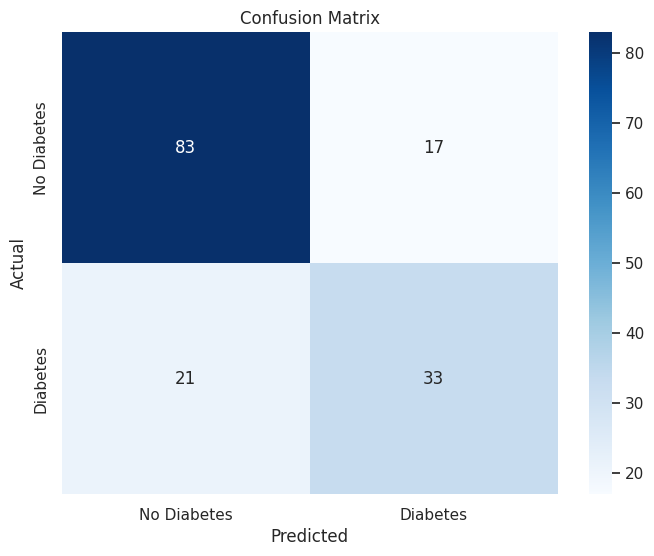

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Diabetes","Diabetes"],yticklabels=["No Diabetes","Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
k_values = range(1,31)

train_accuracy = []
test_accuracy = []

for k in k_values:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_scaled,y_train)
  train_accuracy.append(model.score(X_train_scaled,y_train))
  test_accuracy.append(model.score(X_test_scaled,y_test))

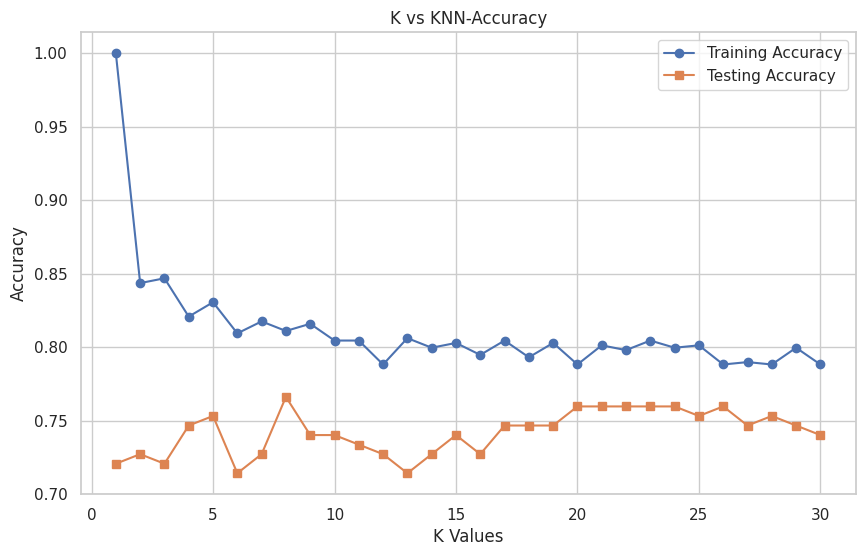

In [37]:
plt.figure(figsize=(10,6))
plt.plot(k_values,train_accuracy,marker ="o",label="Training Accuracy")
plt.plot(k_values,test_accuracy,marker="s",label="Testing Accuracy")
plt.xlabel("K Values")
plt.ylabel("Accuracy")
plt.title("K vs KNN-Accuracy")
plt.legend()
plt.show()

In [38]:
best_k_accuracy  = k_values[np.argmax(test_accuracy)]

best_accuracy = max(test_accuracy)
print("Best K value:",best_k_accuracy)
print("Best Accuracy:",best_accuracy)

Best K value: 8
Best Accuracy: 0.7662337662337663


In [39]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores = []
for k in range(1,31):
  model = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(model,X_train_scaled,y_train,cv=cv,scoring="accuracy")
  cv_scores.append(scores.mean())

In [41]:
best_k_cv = np.argmax(cv_scores) + 1

print("Best K value based on Cross Validation:",best_k_cv)
print("Best CV accuracy based on Cross Validation:",max(cv_scores))


Best K value based on Cross Validation: 13
Best CV accuracy based on Cross Validation: 0.7703718512594963


In [43]:
param_grid = {"n_neighbors":list(range(3,31,2)),"weights":["uniform","distance"],"metric":["euclidean","manhattan","minkowski"],"p":[1,2]}
grid_search = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23,
                                         25, 27, 29],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [45]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}
Best cross-validation score: 0.7769025723044115


In [46]:
best_knn = grid_search.best_estimator_
print(best_knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=19, p=1)


In [47]:
final_pred = best_knn.predict(X_test_scaled)
final_prob = best_knn.predict_proba(X_test_scaled)[:,1]

In [50]:
final_accuracy = accuracy_score(y_test,final_pred)
final_precision = precision_score(y_test,final_pred)
final_recall = recall_score(y_test,final_pred)
final_f1 = f1_score(y_test,final_pred)

print("Final Accuracy:",final_accuracy)
print("Final Precision:",final_precision)
print("Final Recall:",final_recall)
print("Final F1 Score:",final_f1)

Final Accuracy: 0.7467532467532467
Final Precision: 0.6666666666666666
Final Recall: 0.5555555555555556
Final F1 Score: 0.6060606060606061
